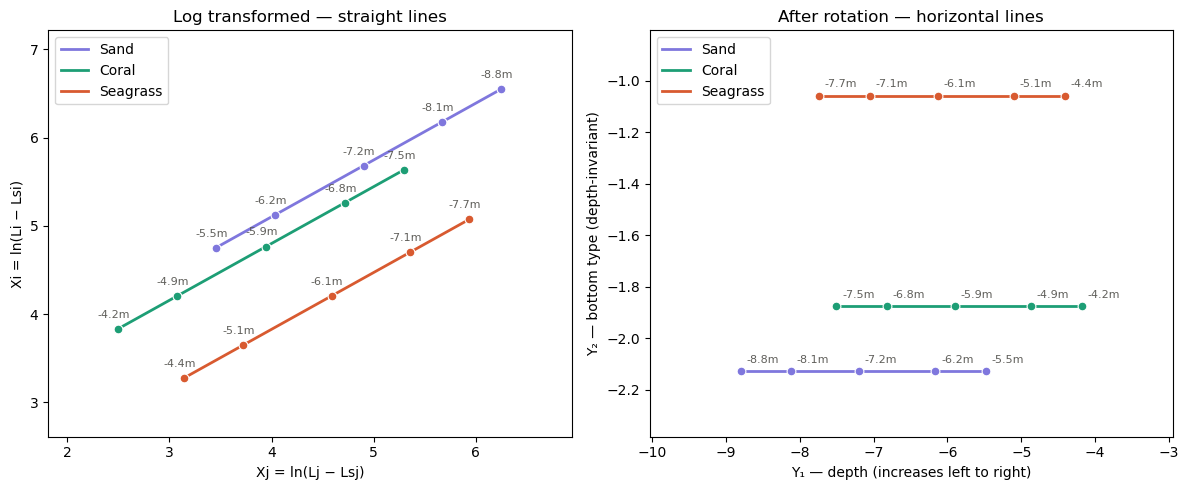

In [128]:
import numpy as np
import matplotlib.pyplot as plt

ki, kj = 0.18, 0.28
depths = np.linspace(0, 10, 30)
Lsi, Lsj = 80, 40

sand     = {"ri": 700, "rj": 520, "label": "Sand",     "color": "#7F77DD"}
coral    = {"ri": 280, "rj": 200, "label": "Coral",    "color": "#1D9E75"}
seagrass = {"ri": 160, "rj": 380, "label": "Seagrass", "color": "#D85A30"}

marker_depths = [0, 2, 5, 8, 10]
marker_indices = [np.argmin(np.abs(depths - d)) for d in marker_depths]

angle = np.arctan2(kj, ki)

def rotate(xi, xj, a):
    u = -(xi * np.cos(a) + xj * np.sin(a))
    v =  -xi * np.sin(a) + xj * np.cos(a)
    return u, v

# fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for t in [sand, coral, seagrass]:
    Li = Lsi + t["ri"] * np.exp(-ki * depths)
    Lj = Lsj + t["rj"] * np.exp(-kj * depths)
    xi = np.log(Li - Lsi)
    xj = np.log(Lj - Lsj)
    u, v = rotate(xi, xj, angle)

    # # panel 1 — raw
    # axes[0].plot(Lj, Li, color=t["color"], label=t["label"], linewidth=2)
    # axes[0].scatter(Lj[marker_indices], Li[marker_indices],
    #                 color=t["color"], s=40, zorder=5, edgecolors='white', linewidths=0.8)
    # for d, idx in zip(marker_depths, marker_indices):
    #     axes[0].annotate(f'{round(u[idx], 1)}m', xy=(Lj[idx], Li[idx]), xytext=(-10, 10),
    #                      textcoords='offset points', fontsize=8, color='#5F5E5A')

    # panel 2 — log transformed
    axes[0].plot(xj, xi, color=t["color"], label=t["label"], linewidth=2)
    axes[0].scatter(xj[marker_indices], xi[marker_indices],
                    color=t["color"], s=40, zorder=5, edgecolors='white', linewidths=0.8)
    for d, idx in zip(marker_depths, marker_indices):
        axes[0].annotate(f'{round(u[idx], 1)}m', xy=(xj[idx], xi[idx]), xytext=(-15, 8),
                         textcoords='offset points', fontsize=8, color='#5F5E5A')

    # panel 3 — rotated
    axes[1].plot(u, v, color=t["color"], label=t["label"], linewidth=2)
    axes[1].scatter(u[marker_indices], v[marker_indices],
                    color=t["color"], s=40, zorder=5, edgecolors='white', linewidths=0.8)
    for d, idx in zip(marker_depths, marker_indices):
        axes[1].annotate(f'{round(u[idx], 1)}m', xy=(u[idx], v[idx]), xytext=(4, 6),
                         textcoords='offset points', fontsize=8, color='#5F5E5A')

# x_min, x_max = axes[0].get_xlim()
# y_min, y_max = axes[0].get_ylim()
# axes[0].set_xlabel("Band j — raw reflectance")
# axes[0].set_ylabel("Band i — raw reflectance")
# axes[0].set_xlim(x_min-50, x_max+100)
# axes[0].set_ylim(y_min-50, y_max+100)
# axes[0].set_title("Raw bands — curves")
# axes[0].legend()

x_min, x_max = axes[0].get_xlim()
y_min, y_max = axes[0].get_ylim()
axes[0].set_xlabel("Xj = ln(Lj − Lsj)")
axes[0].set_ylabel("Xi = ln(Li − Lsi)")
axes[0].set_xlim(x_min-0.5, x_max+0.5)
axes[0].set_ylim(y_min-0.5, y_max+0.5)
axes[0].set_title("Log transformed — straight lines")
axes[0].legend()

x_min, x_max = axes[1].get_xlim()
y_min, y_max = axes[1].get_ylim()
axes[1].set_xlabel("Y\u2081 — depth (increases left to right)")
axes[1].set_ylabel("Y\u2082 — bottom type (depth-invariant)")
axes[1].set_xlim(x_min-1, x_max+1)
axes[1].set_ylim(y_min-0.2, y_max+0.2)
axes[1].set_title("After rotation — horizontal lines")
axes[1].legend()

plt.tight_layout()
plt.show()

Sand
x: [-8.80313261 -8.11444363 -7.19619166 -6.16315819 -5.47446921]

y: [-2.12882236 -2.12882236 -2.12882236 -2.12882236 -2.12882236]

Coral
x: [-7.50388578 -6.8151968  -5.89694483 -4.86391136 -4.17522238]

y: [-1.87475839 -1.87475839 -1.87475839 -1.87475839 -1.87475839]

Seagrass
x: [-7.74118297 -7.05249399 -6.13424202 -5.10120855 -4.41251957]

y: [-1.05693427 -1.05693427 -1.05693427 -1.05693427 -1.05693427]

tick_positions: [-8.80313261 -7.70547935 -6.60782609 -5.51017283 -4.41251957]


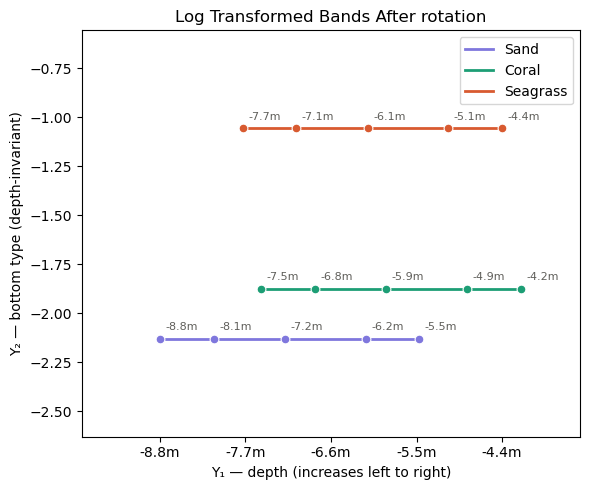

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

ki, kj = 0.18, 0.28
depths = np.linspace(0, 10, 30)

sand     = {"Ai": np.log(700), "Aj": np.log(520), "label": "Sand",     "color": "#7F77DD"}
coral    = {"Ai": np.log(280), "Aj": np.log(200), "label": "Coral",    "color": "#1D9E75"}
seagrass = {"Ai": np.log(160), "Aj": np.log(380), "label": "Seagrass", "color": "#D85A30"}

angle = np.arctan2(kj, ki)

def rotate(xi, xj, a):
    u = -(xi * np.cos(a) + xj * np.sin(a))
    v =  -xi * np.sin(a) + xj * np.cos(a)
    return u, v

marker_depths = [0, 2, 5, 8, 10]
marker_indices = [np.argmin(np.abs(depths - d)) for d in marker_depths]

fig, ax = plt.subplots(figsize=(6, 5))

min_x = 0
min_y = 0
max_x = 0
max_y = 0
for t in [sand, coral, seagrass]:
    xi = t["Ai"] - ki * depths
    xj = t["Aj"] - kj * depths
    u, v = rotate(xi, xj, angle)

    if min_x > min(u[marker_indices]):
        min_x = min(u[marker_indices])
    if min_y > min(v[marker_indices]):
        min_y = min(v[marker_indices])
    if min_x < max(u[marker_indices]):
        max_x = max(u[marker_indices])
    if min_y < max(v[marker_indices]):
        max_y = max(v[marker_indices])
    
    print(t['label'])
    print("x:", u[marker_indices])
    print()
    print("y:", v[marker_indices])
    print()
    ax.plot(u, v, color=t["color"], label=t["label"], linewidth=2)
    ax.scatter(u[marker_indices], v[marker_indices],
               color=t["color"], s=40, zorder=5, edgecolors='white', linewidths=0.8)
    
    for d, idx in zip(marker_depths, marker_indices):
        ax.annotate(f'{round(u[idx], 1)}m', xy=(u[idx], v[idx]), xytext=(4, 6),
                    textcoords='offset points', fontsize=8, color='#5F5E5A')

# Evenly spaced ticks across the x range
x_min, x_max = ax.get_xlim()
tick_positions = np.linspace(min_x, max_x, len(marker_depths))
print("tick_positions:", tick_positions)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f'{round(d, 1)}m' for d in tick_positions])

ax.set_xlabel("Y\u2081 — depth (increases left to right)")
ax.set_ylabel("Y\u2082 — bottom type (depth-invariant)")
ax.set_xlim(min_x-1, max_x+1)
ax.set_ylim(min_y-0.5, max_y+0.5)
ax.set_title("Log Transformed Bands After rotation")
ax.legend()
plt.tight_layout()
plt.show()

2.310541794296664 6.441604383826845


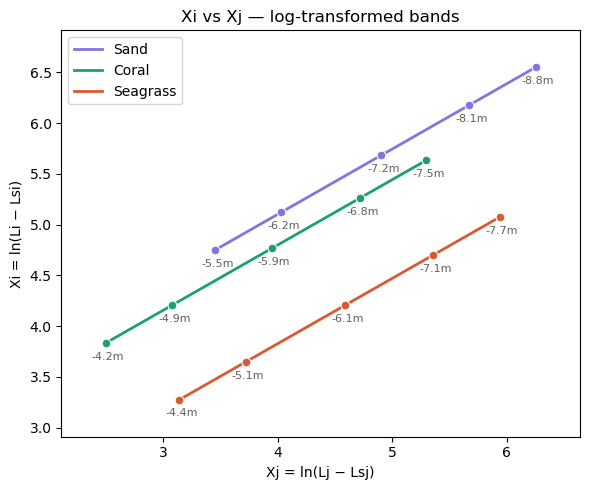

In [99]:
import numpy as np
import matplotlib.pyplot as plt

ki, kj = 0.18, 0.28
depths = np.linspace(0, 10, 30)

sand     = {"Ai": np.log(700), "Aj": np.log(520), "label": "Sand",     "color": "#7F77DD"}
coral    = {"Ai": np.log(280), "Aj": np.log(200), "label": "Coral",    "color": "#1D9E75"}
seagrass = {"Ai": np.log(160), "Aj": np.log(380), "label": "Seagrass", "color": "#D85A30"}

marker_depths = [0, 2, 5, 8, 10]
marker_indices = [np.argmin(np.abs(depths - d)) for d in marker_depths]

fig, ax = plt.subplots(figsize=(6, 5))

for t in [sand, coral, seagrass]:
    xi = t["Ai"] - ki * depths
    xj = t["Aj"] - kj * depths
    u, v = rotate(xi, xj, angle)
    ax.plot(xj, xi, color=t["color"], label=t["label"], linewidth=2)
    ax.scatter(xj[marker_indices], xi[marker_indices],
               color=t["color"], s=40, zorder=5, edgecolors='white', linewidths=0.8)

    for d, idx in zip(marker_depths, marker_indices):
        xi_s = t["Ai"] - ki * depths[idx]
        xj_s = t["Aj"] - kj * depths[idx]
        ax.annotate(f'{round(u[idx], 1)}m', xy=(xj_s, xi_s), xytext=(-10, -12),
                    textcoords='offset points', fontsize=8, color='#5F5E5A')
        
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
print(x_min, x_max)
ax.set_xlabel("Xj = ln(Lj − Lsj)")
ax.set_ylabel("Xi = ln(Li − Lsi)")
ax.set_xlim(x_min-0.2, x_max+0.2)
ax.set_ylim(y_min-0.2, y_max+0.2)
ax.set_title("Xi vs Xj — log-transformed bands")
ax.legend()
plt.tight_layout()
plt.show()

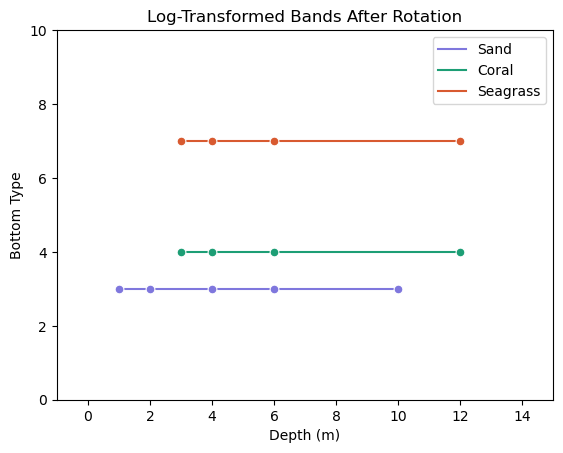

In [37]:
fig, ax = plt.subplots()

x1 = [1, 2, 4, 6, 10]
y1 = [3, 3, 3, 3, 3]

x2 = [3, 4, 6, 12]
y2 = [5, 5, 5, 5]

sand =      {"x": [1, 2, 4, 6, 10], "y": [3, 3, 3, 3, 3],   "label": "Sand",    "color": "#7F77DD"}
coral =     {"x": [3, 4, 6, 12],    "y": [4, 4, 4, 4],      "label": "Coral",    "color": "#1D9E75"}
seagrass =  {"x": [3, 4, 6, 12],    "y": [7, 7, 7, 7],      "label": "Seagrass",    "color": "#D85A30"}

for t in [sand, coral, seagrass]:
    x = t["x"]
    y = t["y"]
    ax.plot(x, y, color=t['color'], label=t["label"])
    ax.scatter(x, y, color=t['color'], s=40, zorder=5, edgecolors='white', linewidths=0.8)

ax.set_xbound(-1, 15)
ax.set_ybound(0, 10)
ax.set_xlabel("Depth (m)")
ax.set_ylabel("Bottom Type")
ax.set_title("Log-Transformed Bands After Rotation")
ax.legend()